AAE 625 Homework3
Elasticity & CPI Data Analysis

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Question1

In [17]:
# Create a demand schedule
demand_data = {
    'Price': [1, 2, 3, 4, 5, 6, 6.5, 7, 8, 9, 10],
    'Quantity': [100, 90, 80, 70, 60, 50, 45, 40, 30, 20, 10]
}

df_demand = pd.DataFrame(demand_data)
df_demand


,Price,Quantity
0,1.0,100
1,2.0,90
2,3.0,80
3,4.0,70
4,5.0,60
5,6.0,50
6,6.5,45
7,7.0,40
8,8.0,30
9,9.0,20


In [18]:
# Compute the price elasticity of demand
df_demand['Price_Elasticity'] = (df_demand['Quantity'].pct_change() / df_demand['Price'].pct_change()).abs()
df_demand  


,Price,Quantity,Price_Elasticity
0,1.0,100,NaN
1,2.0,90,0.100000
2,3.0,80,0.222222
3,4.0,70,0.375000
4,5.0,60,0.571429
5,6.0,50,0.833333
6,6.5,45,1.200000
7,7.0,40,1.444444
8,8.0,30,1.750000
9,9.0,20,2.666667


# Question2

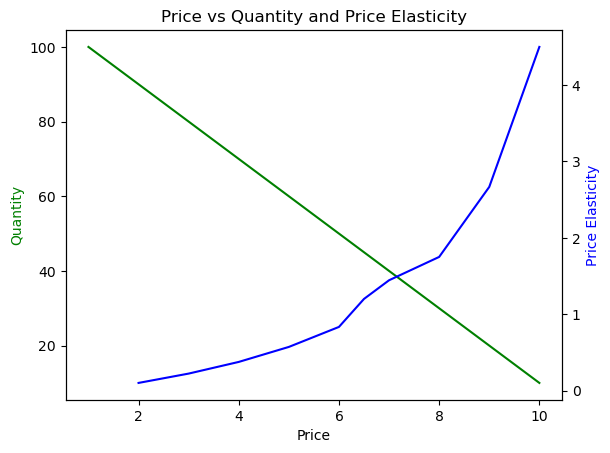

In [19]:
# Plot a dual-axis graph of price and quantity
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(df_demand['Price'], df_demand['Quantity'], 'g-')
ax2.plot(df_demand['Price'], df_demand['Price_Elasticity'], 'b-')
ax1.set_xlabel('Price')
ax1.set_ylabel('Quantity', color='g')
ax2.set_ylabel('Price Elasticity', color='b')
plt.title('Price vs Quantity and Price Elasticity')
plt.show()

# Question3

In [20]:
# import the data
retail = pd.read_csv('/Users/zoerivers/Documents/AAE 625/AAE625_2026/RetailData.csv', sep='|')
retail.head()
retail.columns


Index(['Unnamed: 0', 'STORE_ID', 'PRICE', 'QUANTITY', 'REVENUE',
       'AVERAGE_LENGTH_OF_RESIDENCE', 'PERCENTAGE_OF_RENTERS',
       'PERCENT_HAVING_CHILDREN', 'AVERAGE_INCOME', 'AVERAGE_AGE_IN_YEARS',
       'PERCENT_SPEAKING_SPANISH'],
      dtype='object')

In [21]:
# take the logarithm of all the variables and establish a log-log regression model to
# estimate the price elasticity of demand
retail['ln_Q'] = np.log(retail['QUANTITY'])
retail['ln_P'] = np.log(retail['PRICE'])
retail['ln_R'] = np.log(retail['PERCENTAGE_OF_RENTERS'])
retail['ln_C'] = np.log(retail['PERCENT_HAVING_CHILDREN'])
retail['ln_I'] = np.log(retail['AVERAGE_INCOME'])
retail['ln_S'] = np.log(retail['PERCENT_SPEAKING_SPANISH'])


X = retail[['ln_P','ln_R','ln_C','ln_I','ln_S']]
X = sm.add_constant(X)

y = retail['ln_Q']

model = sm.OLS(y, X).fit()

print(model.summary())




                            OLS Regression Results                            
Dep. Variable:                   ln_Q   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     113.1
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.47e-65
Time:                        15:01:13   Log-Likelihood:                -30.391
No. Observations:                 291   AIC:                             72.78
Df Residuals:                     285   BIC:                             94.82
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7401      0.706     12.373      0.0

1. The estimated price elasticity of demand is the coefficient on ln_P, which is -0.642.
2. Since the absolute value is less than 1, demand is inelastic, meaning quantity demanded is relatively insensitive to price changes.
3. The coefficient is statistically significant at the 5% level because the p-value is 0.011.
4. The demographic variables also have significant effects on demand. Areas with a higher percentage of renters, households with children, and Spanish-speaking residents tend to have higher demand, as indicated by the positive and statistically significant coefficients.
5. The coefficient on income (ln_I = 0.555) means that a 1% increase in income is associated with approximately a 0.56% increase in quantity sold, holding other variables constant.

# Question4

First 5 rows:
                  CPIAUCSL
observation_date          
1947-01-01           21.48
1947-02-01           21.62
1947-03-01           22.00
1947-04-01           22.00
1947-05-01           21.95

Last 5 rows:
                  CPIAUCSL
observation_date          
2025-10-01             NaN
2025-11-01         325.063
2025-12-01         326.031
2026-01-01         326.588
2026-02-01         327.460

Number of observations: 950
Date range: 1947-01-01 00:00:00 to 2026-02-01 00:00:00
Missing values:
CPIAUCSL    1
dtype: int64


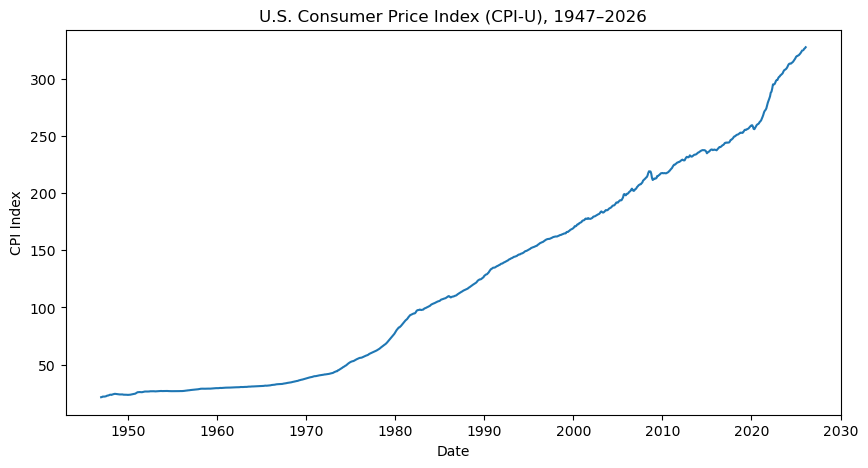

In [22]:
# import the data
cpi = pd.read_excel('/Users/zoerivers/Documents/AAE 625/AAE625_2026/CPIAUCSL_26.xlsx', sheet_name='Monthly')
cpi.head()
cpi.columns

# Keep only the two useful columns
cpi = cpi[['observation_date', 'CPIAUCSL']]

# Convert date column to datetime and set as index
cpi['observation_date'] = pd.to_datetime(cpi['observation_date'])
cpi = cpi.set_index('observation_date')

# Display first and last 5 rows
print("First 5 rows:")
print(cpi.head())

print("\nLast 5 rows:")
print(cpi.tail())

# Report observations, date range, and missing values
print("\nNumber of observations:", len(cpi))
print("Date range:", cpi.index.min(), "to", cpi.index.max())
print("Missing values:")
print(cpi.isna().sum())

# Plot CPI level over the full sample
plt.figure(figsize=(10, 5))
plt.plot(cpi.index, cpi['CPIAUCSL'])
plt.title('U.S. Consumer Price Index (CPI-U), 1947–2026')
plt.xlabel('Date')
plt.ylabel('CPI Index')
plt.show()

Report
1. The dataset contains 950 monthly observations. 
2. The date range is from January 1947 to February 2026. 
3. There is 1 missing value in the CPI series.
4. Overall, the CPI level shows a clear long-run upward trend over time.

# Question5

                  CPIAUCSL    CPI_YoY
observation_date                     
1947-01-01           21.48        NaN
1947-02-01           21.62        NaN
1947-03-01           22.00        NaN
1947-04-01           22.00        NaN
1947-05-01           21.95        NaN
1947-06-01           22.08        NaN
1947-07-01           22.23        NaN
1947-08-01           22.40        NaN
1947-09-01           22.84        NaN
1947-10-01           22.91        NaN
1947-11-01           23.06        NaN
1947-12-01           23.41        NaN
1948-01-01           23.68  10.242086
1948-02-01           23.67   9.481961
1948-03-01           23.50   6.818182


/var/folders/8s/fmp72fxn76d8vczwqmy1bbjc0000gn/T/ipykernel_32699/868530055.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi['CPI_YoY'] = cpi['CPIAUCSL'].pct_change(periods=12) * 100


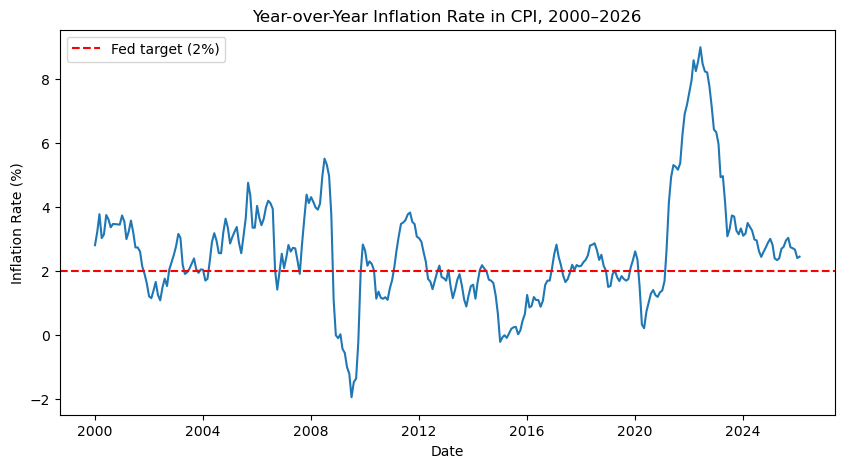

2.391201432150014
Highest YoY inflation: 8.979361103105798
Occurred in: 2022-06-01 00:00:00


In [25]:
# Caculate the year-over-year inflation rate in CPI
cpi['CPI_YoY'] = cpi['CPIAUCSL'].pct_change(periods=12) * 100
cpi.head(15)
print(cpi.head(15))

# Plot the year-over-year inflation rate in CPI from 2000 to 2026
plt.figure(figsize=(10,5))
plt.plot(cpi_2000_2026.index, cpi_2000_2026['CPI_YoY'])
plt.axhline(y=2, color='red', linestyle='--', label='Fed target (2%)')
plt.title('Year-over-Year Inflation Rate in CPI, 2000–2026')
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.legend()
plt.show()

# Caculate the YoY inflation rate for January 2026
cpi_jan_2026 = cpi.loc['2026-01-01']
print(cpi_jan_2026['CPI_YoY'])

# Find the highest YoY inflation rate since 2000 with the data
cpi_2000_2026 = cpi['2000':'2026']

max_rate = cpi_2000_2026['CPI_YoY'].max()
max_date = cpi_2000_2026['CPI_YoY'].idxmax()

print("Highest YoY inflation:", max_rate)
print("Occurred in:", max_date)

* c. The year-over-year inflation rate for January 2026 is 2.39%.  
This means that the CPI in January 2026 is about 2.39% higher than in January 2025.
* d. The highest year-over-year inflation since 2000 occurred in June 2022, with a rate of 8.98%.
This surge in inflation was mainly driven by the economic recovery after COVID-19, supply chain disruptions, strong consumer demand, and high energy and food prices. During this period, inflation rose significantly above the Federal Reserve’s 2% target.

# Question6

                  CPIAUCSL    CPI_YoY   CPI_MoM
observation_date                               
1947-01-01           21.48        NaN       NaN
1947-02-01           21.62        NaN  0.651769
1947-03-01           22.00        NaN  1.757632
1947-04-01           22.00        NaN  0.000000
1947-05-01           21.95        NaN -0.227273
1947-06-01           22.08        NaN  0.592255
1947-07-01           22.23        NaN  0.679348
1947-08-01           22.40        NaN  0.764732
1947-09-01           22.84        NaN  1.964286
1947-10-01           22.91        NaN  0.306480
1947-11-01           23.06        NaN  0.654736
1947-12-01           23.41        NaN  1.517780
1948-01-01           23.68  10.242086  1.153353
1948-02-01           23.67   9.481961 -0.042230
1948-03-01           23.50   6.818182 -0.718209
                  CPIAUCSL   CPI_YoY   CPI_MoM
observation_date                              
2024-12-01         317.604  2.870691  0.339938
2025-01-01         318.961  2.990978  0.427

/var/folders/8s/fmp72fxn76d8vczwqmy1bbjc0000gn/T/ipykernel_32699/2600013519.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi['CPI_MoM'] = cpi['CPIAUCSL'].pct_change() * 100


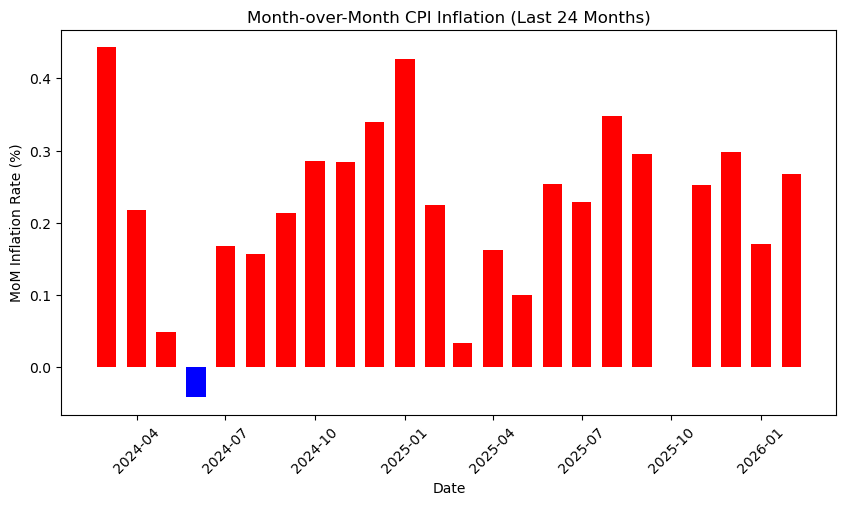

In [32]:
# Caculate the month-to-month inflation rate in CPI
cpi['CPI_MoM'] = cpi['CPIAUCSL'].pct_change() * 100
cpi.head(15)
cpi.tail(15)
print(cpi.head(15))
print(cpi.tail(15))

# Create a bar chart of the month-to-month inflation rate in CPI for the last 24 months
cpi_recent = cpi.tail(24)
colors = ['red' if x > 0 else 'blue' for x in cpi_recent['CPI_MoM']]
plt.figure(figsize=(10,5))
plt.bar(cpi_recent.index, cpi_recent['CPI_MoM'], color=colors, width=20)
plt.title('Month-over-Month CPI Inflation (Last 24 Months)')
plt.xlabel('Date')
plt.ylabel('MoM Inflation Rate (%)')
plt.xticks(rotation=45)
plt.show()


Economists and policymakers usually prefer year-over-year inflation because it reflects longer-term inflation trends and reduces short-term volatility.
Month-over-month inflation can fluctuate significantly due to temporary shocks or seasonal effects, while YoY inflation provides a more stable measure of overall inflation.

# Question7

2000–2007: 2.7768560912199853
2008–2009: 1.759151510025383
2010–2019: 1.7712719768810719
2020–2023: 4.518981102797763
2024–2026: 2.792969850432238


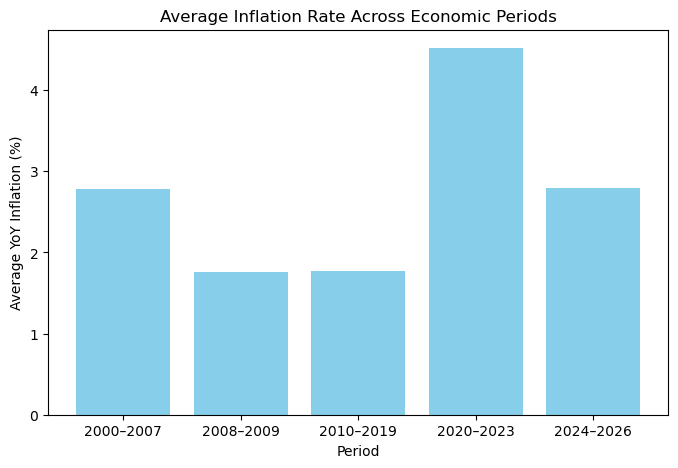

In [33]:
# Define periods and calculate average YoY inflation for each period
period1 = cpi.loc['2000':'2007', 'CPI_YoY'].mean()
period2 = cpi.loc['2008':'2009', 'CPI_YoY'].mean()
period3 = cpi.loc['2010':'2019', 'CPI_YoY'].mean()
period4 = cpi.loc['2020':'2023', 'CPI_YoY'].mean()
period5 = cpi.loc['2024':'2026', 'CPI_YoY'].mean()

print("2000–2007:", period1)
print("2008–2009:", period2)
print("2010–2019:", period3)
print("2020–2023:", period4)
print("2024–2026:", period5)

# Create a bar chart comparing the average YoY inflation rates across the defined periods
periods = [
    '2000–2007',
    '2008–2009',
    '2010–2019',
    '2020–2023',
    '2024–2026'
]

inflation_avg = [
    period1,
    period2,
    period3,
    period4,
    period5
]

plt.figure(figsize=(8,5))
plt.bar(periods, inflation_avg, color='skyblue')
plt.title('Average Inflation Rate Across Economic Periods')
plt.xlabel('Period')
plt.ylabel('Average YoY Inflation (%)')
plt.show()

* 2000–2007 (Pre-Financial Crisis)

The average inflation rate during 2000–2007 was about 2.78%.  
Economic growth and strong consumer demand contributed to moderate demand-pull inflation. Rising energy prices also created some cost-push pressure.

* 2008–2009 (Great Recession)

The average inflation rate during 2008–2009 was about 1.76%.  
The global financial crisis caused a sharp decline in economic activity and consumer demand. Weak demand reduced inflation and created downward pressure on prices.

* 2010–2019 (Post-Recovery / Low Inflation Era)

During 2010–2019, the average inflation rate was about 1.77%.  
Inflation remained relatively low due to stable energy prices and moderate economic growth. Monetary policy remained accommodative, but inflation stayed close to the Federal Reserve’s 2% target.

* 2020–2023 (COVID & Post-COVID Inflation)

Inflation rose significantly during 2020–2023, with an average of 4.52%.  
Supply chain disruptions, higher energy prices, and strong fiscal stimulus increased both cost-push and demand-pull inflation after the COVID-19 pandemic.

* 2024–2026 (Current Period)

The average inflation rate during 2024–2026 is about 2.79%.  
Inflation has moderated as supply chains recovered and the Federal Reserve tightened monetary policy through higher interest rates.